### Time to get your hands dirty. Galaxy vs quasars

We're now going to classify galaxy vs quasars in the Sloan Digital Sky Survey. 

This is one of the most famous example of machine-learning classification in astronomy. For some recent work see e.g. 
- *Identifying galaxies, quasars, and stars with machine learning: A new catalogue of classifications for 111 million SDSS sources without spectra* Clarke et al (2019) [arXiv:1909.10963](https://arxiv.org/abs/1909.10963)
- *Quasar and galaxy classification in Gaia Data Release 2* Bailer-Jones et al (2019) [arXiv:1910.05255](https://arxiv.org/abs/1910.05255)

Some figures from the second paper:

#### Data

The dataset is at `solutions/galaxyquasar.csv`. I have extracted it myself from the SDSS database using the SQL query reported [here](https://www.astroml.org/_modules/astroML/datasets/sdss_galaxy_colors.html#fetch_sdss_galaxy_colors)

(If you've never used [SQL](https://en.wikipedia.org/wiki/SQL) and want to learn something new it's computing, it's very powerful)

#### Tasks

- Create arrays for the $(u-g)$, $(g-r)$, $(r-i)$, and $(i-z)$ colors. Also create an array with the class labels where galaxy=$0$ and quasar=$1$. 
- Classify the dataset against the target label.
- Try some of the classification methods we've seen so far and evaluate the performance using the ROC curve.
- Remember to split the dataset into training and validation...

#### Ideas
- Try using different colors (a subset of them first, than all together). Which is the most important feature?
- What are the colors that better satisfy or invalidate the "Naive" assumption of independence between the attributes?

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd



In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from astroML.datasets import fetch_rrlyrae_combined
from astroML.utils import completeness_contamination

from sklearn.model_selection import cross_val_predict
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_curve
from sklearn.metrics import precision_recall_curve


In [15]:
file_path = "~/uni/astrostatistics_bicocca_2025/solutions/galaxyquasar.csv"
data = pd.read_csv(file_path)

u_g = data['u'].values - data['g'].values
g_r = data['g'].values - data['r'].values 
r_i = data['r'].values - data['i'].values
i_z = data['i'].values - data['z'].values  
 
idx = np.where(data['class'] == "QSO")[0]

labels = np.zeros(len(data))
labels[idx] = 1

In [20]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split

u_g = u_g.reshape(-1, 1)
g_r = g_r.reshape(-1, 1)
gnb = GaussianNB()
gnb.fit(u_g,g_r)

/home/leo/.cache/pypoetry/virtualenvs/working-ea1cCKUn-py3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


ValueError: Unknown label type: (array([-10.44802,  -9.25137,  -7.91879, ...,   3.84958,   3.89119,
         3.99707]),)

QUESTO è TUTTO SBAGLIATO -> prima faccio un paio di plot per visulaizzare i dati, poi slit test e train, poi faccio predictions e ROC curve

NameError: name 'ax' is not defined

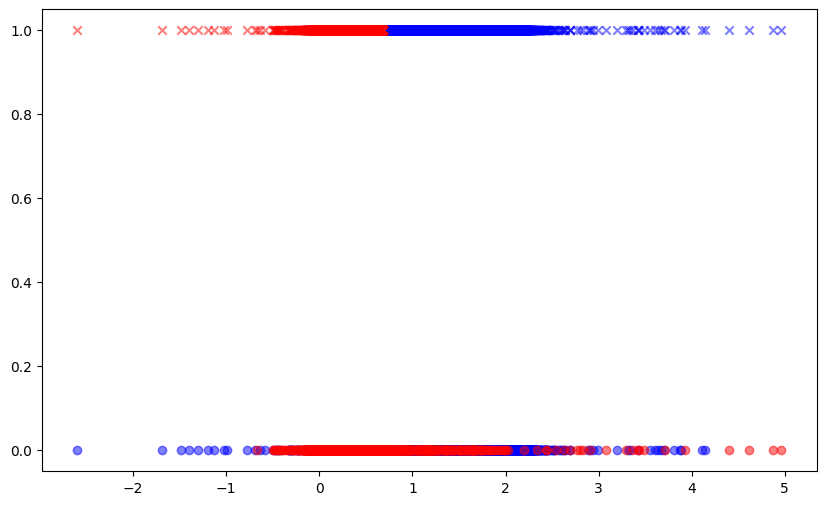

In [ ]:
y_pred = gnb.predict(u_g)

#plot the results
plt.figure(figsize=(10, 6))
plt.scatter(u_g[labels == 0], np.zeros(len(u_g[labels == 0])), color='blue', label='Galaxy', alpha=0.5)
plt.scatter(u_g[labels == 1], np.zeros(len(u_g[labels == 1])), color='red', label='QSO', alpha=0.5)
plt.scatter(u_g[y_pred == 0], np.ones(len(u_g[y_pred == 0])), color='blue', marker='x', label='Predicted Galaxy', alpha=0.5)
plt.scatter(u_g[y_pred == 1], np.ones(len(u_g[y_pred == 1])), color='red', marker='x', label='Predicted QSO', alpha=0.5)

plt.title('Naive Bayes Classifier Results')
plt.xlabel('u-g')
plt.ylabel('Predicted Class')
plt.legend()
plt.show()